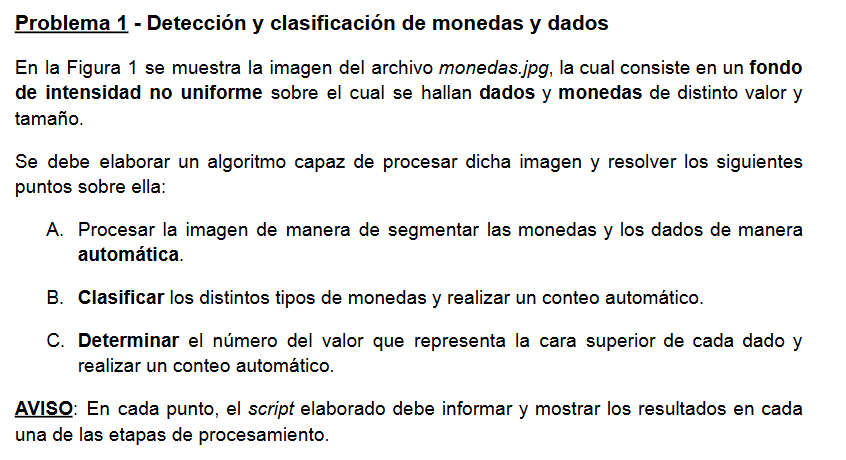

In [21]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# PARTE A

tecnica top-hat (PI_U6_Morfologico_pt_grises.py)

In [22]:
img_color = cv2.imread('img/monedas.jpg')
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

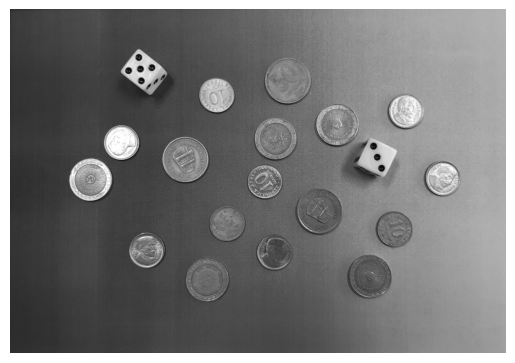

In [23]:
gray_blur = cv2.GaussianBlur(gray, (3, 3), 1)

plt.imshow(gray_blur, cmap='gray')
plt.axis('off')
plt.show()

usar top-hat para aplanar el fondo (PI_U6_Morfologico_pt_grises.py)

getStructuringElement:

cv2.MORPH_ELLIPSE: Le dice a OpenCV que la forma sea una elipse (un círculo). Elegimos esto porque tus objetos (las monedas) son redondos.

(35, 35): Este es el tamaño de la elipse (35x35 píxeles). Este tamaño es la clave: debe ser más grande que los objetos que quieres encontrar.

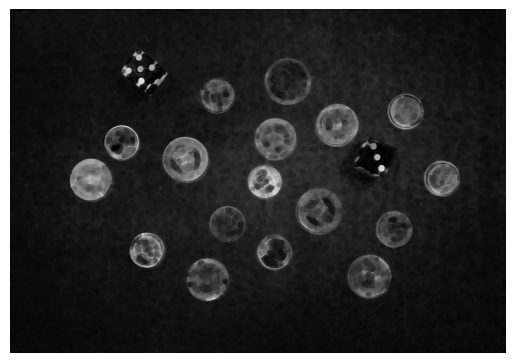

In [24]:
# Operaciones Top-Hat y Black-Hat
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))

# Top-Hat 
# Lo usamos para encontrar todos los objetos brillantes en la imagen que son más pequeños que el kernel.
tophat = cv2.morphologyEx(gray_blur, cv2.MORPH_TOPHAT, kernel)

# Black-Hat
# Lo usamos para encontrar todos los objetos oscuros en la imagen que son más pequeños que el kernel.
blackhat = cv2.morphologyEx(gray_blur, cv2.MORPH_BLACKHAT, kernel)

# combinar mascaras
# Obtiene una única imagen donde el fondo no uniforme ha sido completamente eliminado (es negro) y todos los objetos (brillantes y oscuros) están resaltados.
mask = cv2.add(tophat, blackhat)

plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

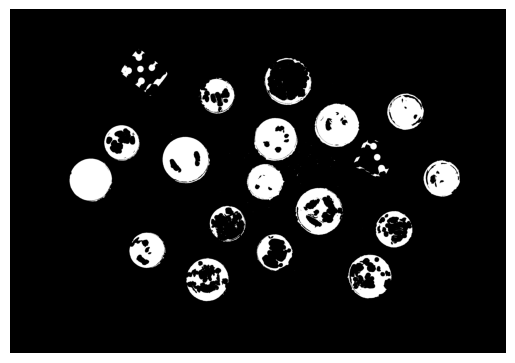

In [25]:
#umbralado
ret, mask_thresh = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(mask_thresh, cmap='gray')
plt.axis('off')
plt.show()

In [26]:
# componenes conectadas
(num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    mask_thresh, 8, cv2.CV_32S
) 

output_image = img_color.copy()
objetos_reales = 0

for i in range(1, num_labels): # Empezamos en 1 para saltar el fondo
    area = stats[i, cv2.CC_STAT_AREA]
    
    # filtramos objetos muy pequeños (ruido)
    if area < 8000: 
        continue
    
    objetos_reales += 1
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    
    cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    (cX, cY) = centroids[i] 
    cv2.putText(output_image, str(i), (int(cX) - 10, int(cY)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

print(f"Se encontraron {objetos_reales} objetos.")

Se encontraron 17 objetos.


(np.float64(-0.5), np.float64(3870.5), np.float64(2680.5), np.float64(-0.5))

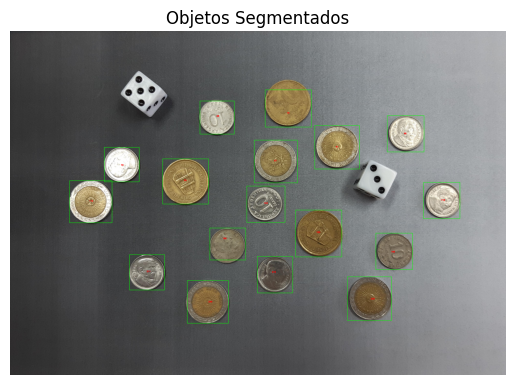

In [27]:
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title('Objetos Segmentados')
plt.axis('off')

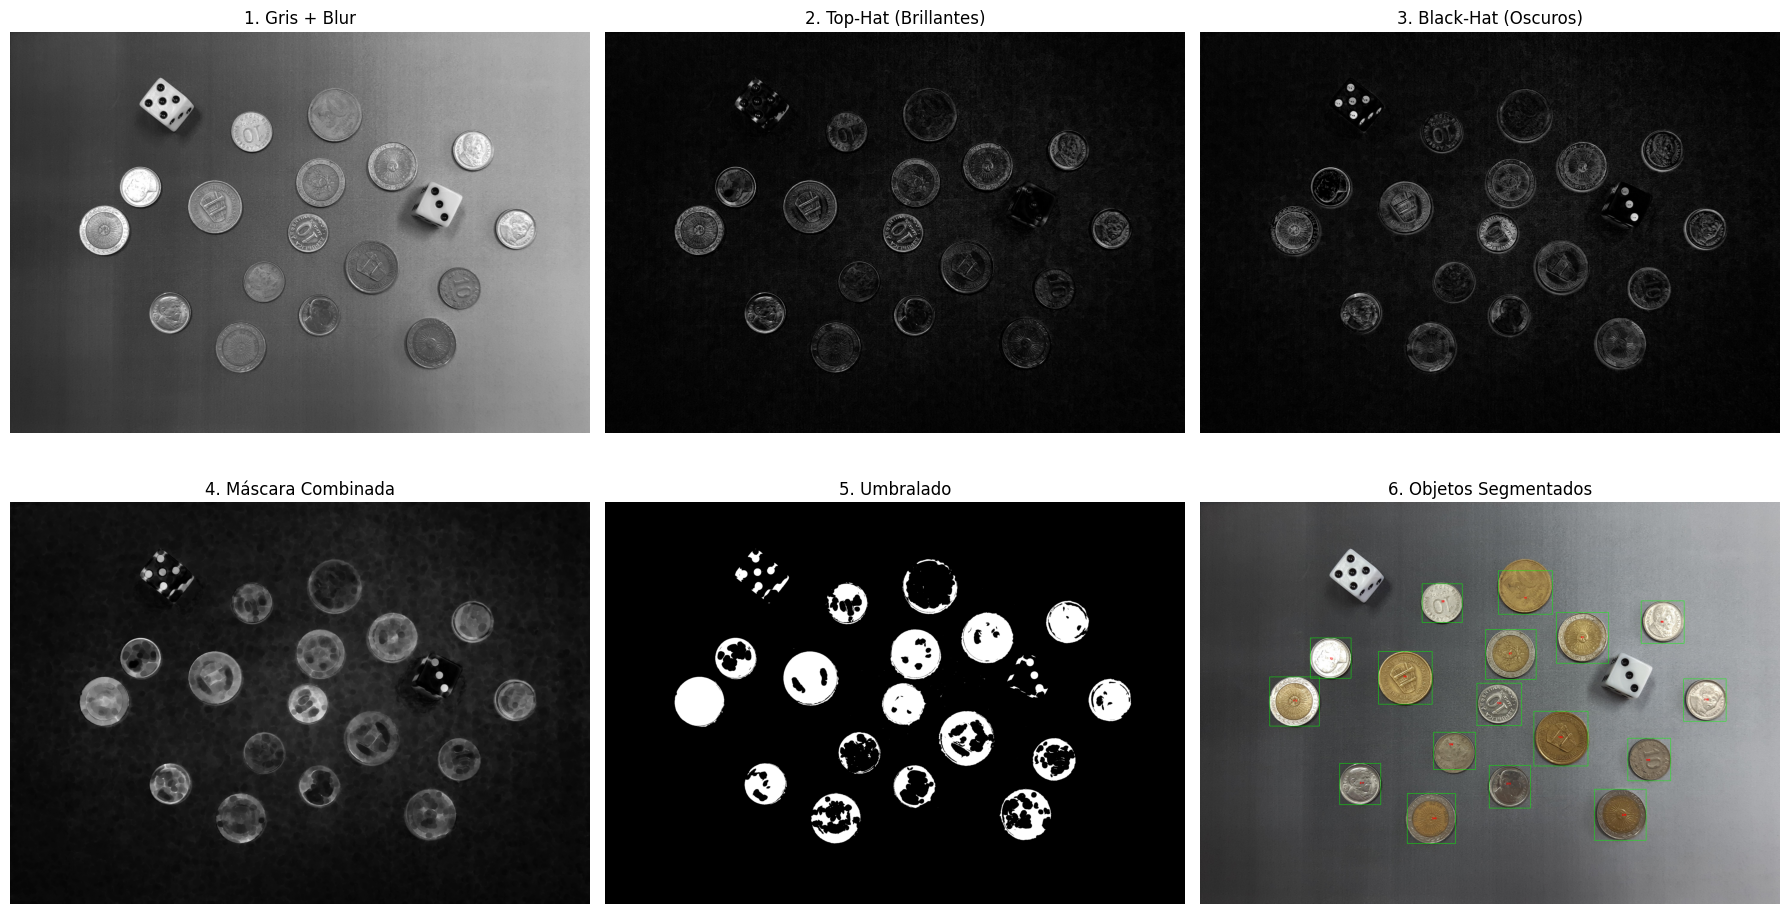

In [28]:
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(gray_blur, cmap='gray')
plt.title('1. Gris + Blur')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(tophat, cmap='gray')
plt.title('2. Top-Hat (Brillantes)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(blackhat, cmap='gray')
plt.title('3. Black-Hat (Oscuros)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(mask, cmap='gray')
plt.title('4. Máscara Combinada')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(mask_thresh, cmap='gray')
plt.title('5. Umbralado')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title('6. Objetos Segmentados')
plt.axis('off')

plt.tight_layout()
plt.show()

Objeto #14: Área=23669 -> Chica
Objeto #20: Área=44047 -> Mediana
Objeto #29: Área=61388 -> Mediana
Objeto #34: Área=89672 -> Grande
Objeto #35: Área=84726 -> Grande
Objeto #38: Área=40863 -> Mediana
Objeto #43: Área=97870 -> Grande
Objeto #58: Área=88351 -> Grande
Objeto #61: Área=60629 -> Mediana
Objeto #64: Área=62090 -> Mediana
Objeto #79: Área=78902 -> Grande
Objeto #85: Área=17906 -> Chica
Objeto #87: Área=36586 -> Mediana
Objeto #111: Área=54073 -> Mediana
Objeto #115: Área=32860 -> Mediana
Objeto #124: Área=58203 -> Mediana
Objeto #125: Área=43999 -> Mediana
- Grande: 5
- Mediana: 10
- Chica: 2

Total de monedas: 17


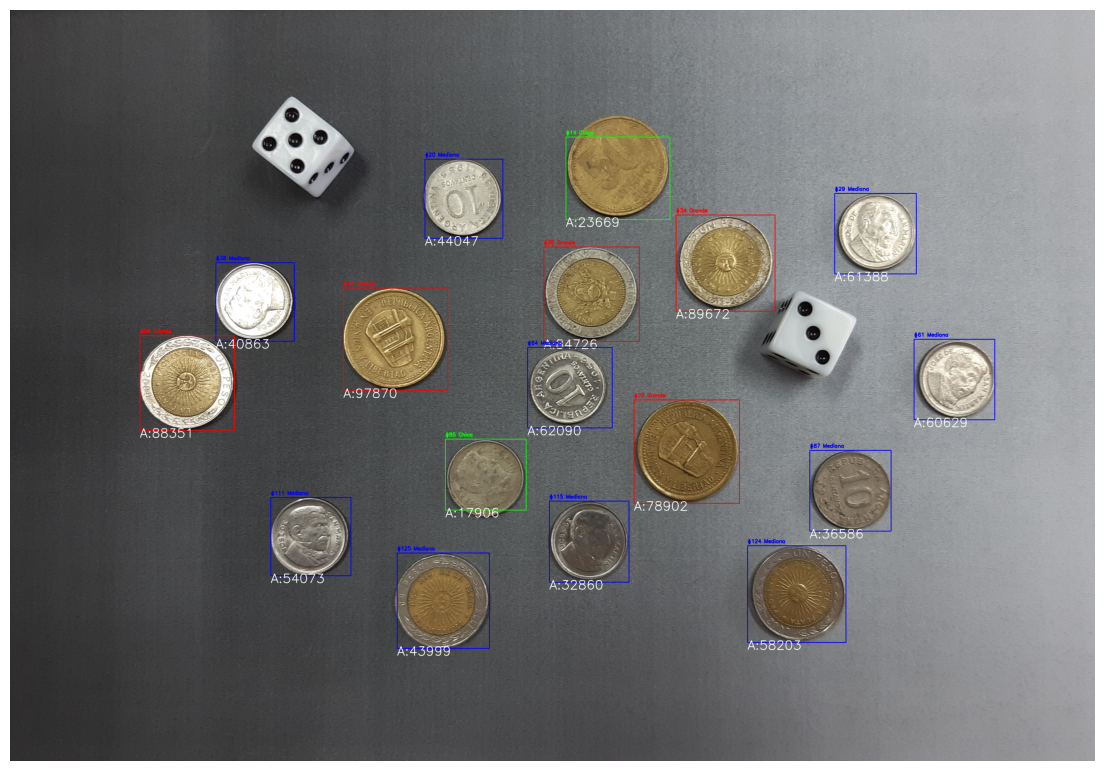

In [52]:
conteo_monedas = {
    "Grande": 0,
    "Mediana": 0,
    "Chica": 0
}

(num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    mask_thresh, 8, cv2.CV_32S
)

output_image = img_color.copy()
objetos_reales = 0

# CALIBRACIÓN DE TAMAÑOS
AREA_MINIMA = 15000
UMBRAL_LIMITE_CHICA = 25000   # Menor a esto es Chica
UMBRAL_LIMITE_MEDIANA = 70000 # Menor a esto es Mediana, Mayor es Grande

for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]

    # Filtro de ruido
    if area < AREA_MINIMA:
        continue

    objetos_reales += 1
    
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    
    if area < UMBRAL_LIMITE_CHICA:
        tipo_tamano = "Chica"
        color_box = (0, 255, 0)    # Verde para chicas
    elif area < UMBRAL_LIMITE_MEDIANA:
        tipo_tamano = "Mediana"
        color_box = (255, 0, 0)    # Azul para medianas
    else:
        tipo_tamano = "Grande"
        color_box = (0, 0, 255)    # Rojo para grandes

    if tipo_tamano in conteo_monedas:
        conteo_monedas[tipo_tamano] += 1
    
    cv2.rectangle(output_image, (x, y), (x + w, y + h), color_box, 2)
    
    texto_etiqueta = f"#{i} {tipo_tamano}"
    cv2.putText(output_image, texto_etiqueta, (x, y - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_box, 2)

    print(f"Objeto #{i}: Área={area} -> {tipo_tamano}")

    texto_area = f"A:{int(area)}"
    cv2.putText(output_image, texto_area, (x, y + h + 25), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 255), 2)

total_monedas = 0
for tipo, cantidad in conteo_monedas.items():
    if cantidad > 0:
        print(f"- {tipo}: {cantidad}")
        total_monedas += cantidad

print(f"\nTotal de monedas: {total_monedas}")

plt.figure(figsize=(14, 12))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()